## Análisis Multivariable

### By:
Karen Ninco

### Date:
2026-08-21

### Description:

#### Requerimiento
Realizar un análisis exploratorio de datos (EDA) para caracterizar los datos disponibles del proyecto, continuando con el análisis multivariable: la relación entre la variable objetivo (`disease`) y múltiples variables predictoras de forma simultánea, buscando identificar combinaciones de variables que ayuden a caracterizar mejor a los pacientes con y sin enfermedad, y como paso previo a la construcción de un modelo base (heurístico).

Tomar como ejemplo los pasos de: https://joserzapata.github.io/post/ciencia-datos-proyecto-python/3-analysis/multivariate-data-analysis/

#### Entregables:
Notebook con el análisis multivariable de los datos.
Se debe realizar un Pull request para ingresar el notebook a la rama main, con mínimo 1 revisión y que pase los checks de CI/CD.

## 📚 Import libraries

In [132]:
# base libraries for data science
import sys
from pathlib import Path

import pandas as pd
import seaborn as sns

pd.set_option("display.float_format", "{:.2f}".format)

print("Python version: ", sys.version)
print("Pandas version: ", pd.__version__)

Python version:  3.12.3 (main, Jun 19 2026, 12:46:00) [GCC 13.3.0]
Pandas version:  3.0.5


## 💾 Load data

In [ ]:
DATA_DIR = Path.cwd().resolve().parents[1] / "data"
corazon_df = pd.read_parquet(DATA_DIR / "02_intermediate/corazon_clean.parquet", engine="pyarrow")

## 📊 Data description

#### General data information

In [134]:
corazon_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   age         2998 non-null   float64 
 1   sex         2966 non-null   category
 2   chest_pain  2944 non-null   category
 3   rest_bp     2947 non-null   float64 
 4   chol        2943 non-null   float64 
 5   fbs         2933 non-null   boolean 
 6   rest_ecg    2832 non-null   category
 7   max_hr      2858 non-null   Int16   
 8   exang       2877 non-null   boolean 
 9   old_peak    2878 non-null   float64 
 10  slope       2878 non-null   category
 11  ca          2867 non-null   Int8    
 12  thal        2900 non-null   category
 13  disease     2919 non-null   boolean 
dtypes: Int16(1), Int8(1), boolean(3), category(5), float64(4)
memory usage: 142.5 KB


#### Size of the dataset

In [135]:
corazon_df.shape

(3030, 14)

#### Sample of the dataset

In [136]:
corazon_df.sample(5)

,age,sex,chest_pain,rest_bp,chol,fbs,rest_ecg,max_hr,exang,old_peak,slope,ca,thal,disease
2296,57.00,Male,asymptomatic,152.00,274.00,False,normal,88,True,1.20,2,1,reversable,True
2805,48.00,Male,nontypical,130.00,245.00,False,left ventricular hypertrophy,180,False,0.20,2,0,normal,False
2709,58.00,Male,asymptomatic,114.00,318.00,False,ST-T wave abnormality,140,False,4.40,3,3,fixed,True
232,49.00,Male,nonanginal,118.00,149.00,False,left ventricular hypertrophy,126,False,0.80,1,3,normal,True
1457,67.00,Male,asymptomatic,120.00,237.00,False,normal,71,False,1.00,2,0,normal,True


#### Number of missing values

In [137]:
corazon_df.isnull().sum()

age            32
sex            64
chest_pain     86
rest_bp        83
chol           87
fbs            97
rest_ecg      198
max_hr        172
exang         153
old_peak      152
slope         152
ca            163
thal          130
disease       111
dtype: int64

Target Variable = disease

### General statistics of the data set

#### Numerical variables

In [138]:
corazon_df.describe()

,age,rest_bp,chol,max_hr,old_peak,ca
count,2998.00,2947.00,2943.00,2858.00,2878.00,2867.00
mean,54.46,131.62,246.72,149.56,1.04,0.67
std,9.02,17.57,51.60,22.88,1.16,0.94
min,29.00,94.00,126.00,71.00,0.00,0.00
25%,48.00,120.00,211.00,133.00,0.00,0.00
50%,56.00,130.00,241.00,153.00,0.80,0.00
75%,61.00,140.00,275.00,166.00,1.60,1.00
max,77.00,200.00,564.00,202.00,6.20,3.00


#### Categorical variables

In [139]:
corazon_df.describe(include="category")

,sex,chest_pain,rest_ecg,slope,thal
count,2966,2944,2832,2878,2900
unique,2,4,3,3,3
top,Male,asymptomatic,normal,1,normal
freq,2017,1394,1409,1353,1599


## 📈 Multivariate Analysis

En esta sección se revisa la relación entre la variable objetivo (`disease`) y múltiples variables de forma simultánea, combinando variables numéricas y categóricas, con el fin de identificar patrones que no son evidentes al analizar las variables de a una o de a pares.

### Target vs age vs sex

In [140]:
corazon_df[["sex", "age", "disease"]].isnull().sum()

sex         64
age         32
disease    111
dtype: int64

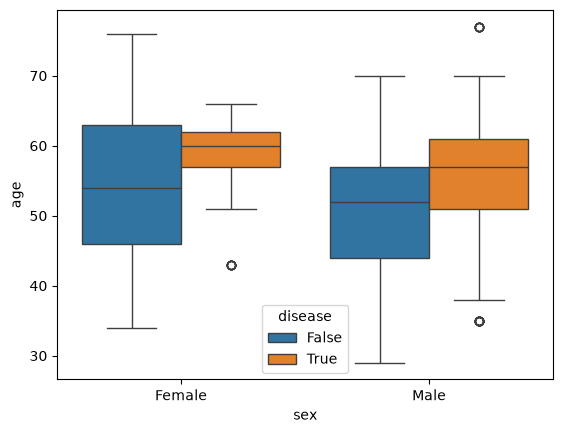

In [141]:
sns.boxplot(
    data=corazon_df.dropna(subset=["sex", "age", "disease"]),
    x="sex",
    y="age",
    hue="disease",
);

### Target vs age vs chest_pain

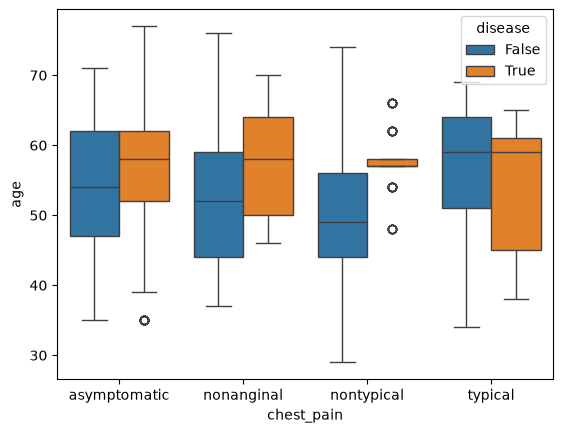

In [142]:
sns.boxplot(
    data=corazon_df.dropna(subset=["chest_pain", "age", "disease"]),
    x="chest_pain",
    y="age",
    hue="disease",
);

### Target vs age vs exang

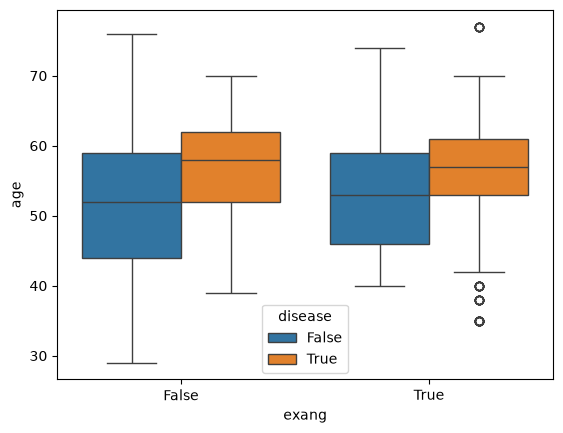

In [143]:
sns.boxplot(
    data=corazon_df.dropna(subset=["exang", "age", "disease"]),
    x="exang",
    y="age",
    hue="disease",
);

### Target vs age vs slope

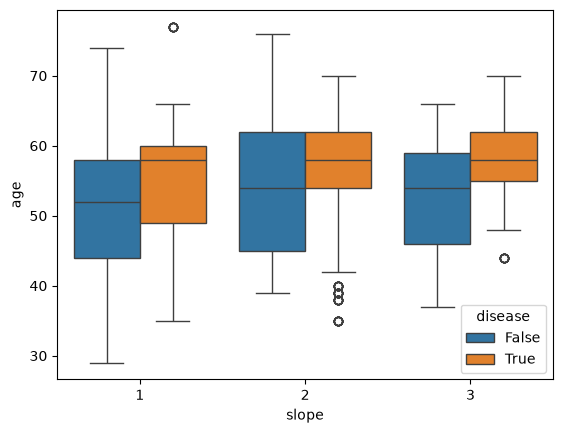

In [144]:
sns.boxplot(
    data=corazon_df.dropna(subset=["slope", "age", "disease"]),
    x="slope",
    y="age",
    hue="disease",
);

### Target vs age vs thal

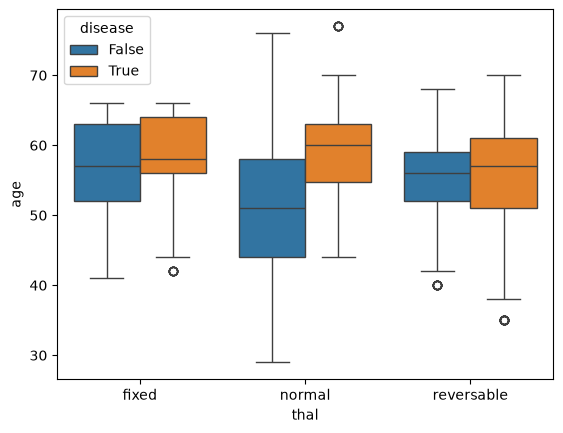

In [145]:
sns.boxplot(
    data=corazon_df.dropna(subset=["thal", "age", "disease"]),
    x="thal",
    y="age",
    hue="disease",
);

### Target vs sex vs thal

In [ ]:
(
    corazon_df[["sex", "thal", "disease"]].groupby(["thal", "sex"], observed=True).mean() * 100,
    1,
)

(                   disease
 thal       sex            
 fixed      Female   100.00
            Male      65.82
 normal     Female    14.27
            Male      29.77
 reversable Female    87.32
            Male      74.51,
 1)

En todas las categorías de `thal`, las mujeres presentan un porcentaje de enfermedad mayor que los hombres: en `fixed` el 100% de las mujeres tiene enfermedad frente al 65.8% de los hombres, y en `reversable` 87.3% frente a 74.5%. La excepción es `normal`, donde el porcentaje es bajo para ambos sexos (14.3% mujeres, 29.8% hombres), siendo la única categoría de `thal` donde los hombres superan a las mujeres.

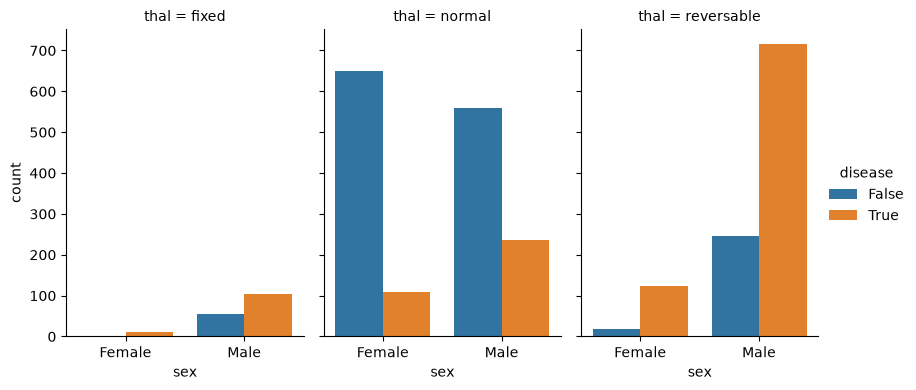

In [147]:
sns.catplot(
    data=corazon_df.dropna(subset=["sex", "thal", "disease"]),
    x="sex",
    hue="disease",
    col="thal",
    kind="count",
    height=4,
    aspect=0.7,
);

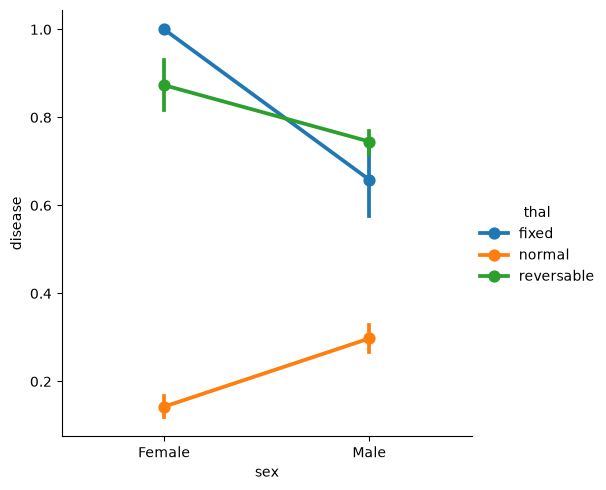

In [148]:
sns.catplot(
    data=corazon_df.dropna(subset=["sex", "thal", "disease"]),
    x="sex",
    y="disease",
    hue="thal",
    kind="point",
);

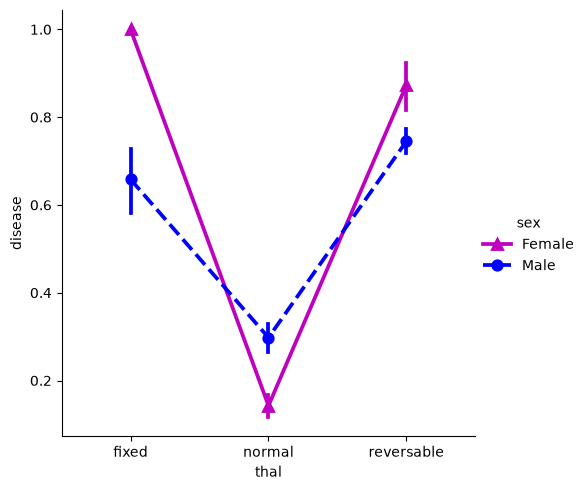

In [149]:
sns.catplot(
    data=corazon_df.dropna(subset=["sex", "thal", "disease"]),
    x="thal",
    y="disease",
    hue="sex",
    palette={"Male": "b", "Female": "m"},
    markers=["^", "o"],
    linestyles=["-", "--"],
    kind="point",
);

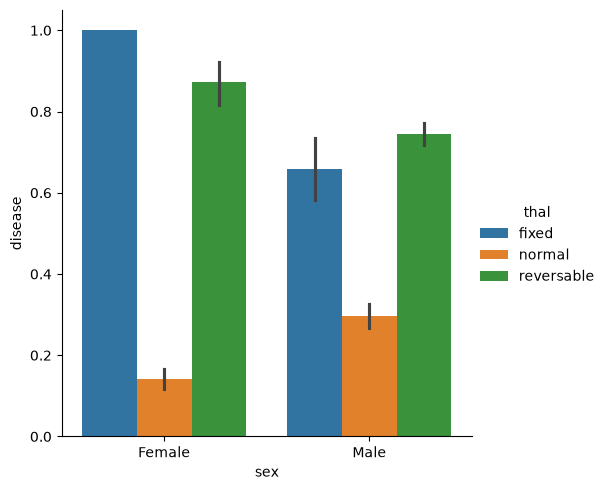

In [150]:
sns.catplot(
    data=corazon_df.dropna(subset=["sex", "thal", "disease"]),
    x="sex",
    y="disease",
    hue="thal",
    kind="bar",
);

### Target vs thal vs max_hr

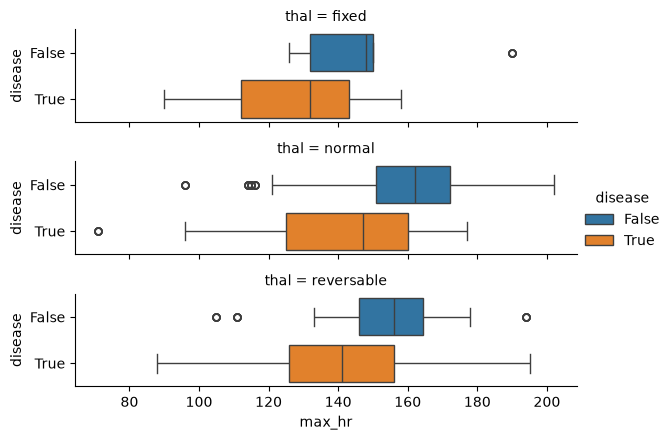

In [151]:
sns.catplot(
    x="max_hr",
    y="disease",
    row="thal",
    kind="box",
    hue="disease",
    orient="h",
    height=1.5,
    aspect=4,
    data=corazon_df.dropna(subset=["max_hr", "thal", "disease"]),
).set();

### Target vs sex vs thal vs exang

In [152]:
(
    corazon_df[["exang", "sex", "thal", "disease"]]
    .groupby(["exang", "thal", "sex"], observed=True)
    .agg(["count", "mean"])
)

disease     
                          count mean
exang thal       sex                
False fixed      Male        90 0.50
      normal     Female     624 0.09
                 Male       616 0.23
      reversable Female      64 0.73
                 Male       465 0.61
True  fixed      Female       9 1.00
                 Male        65 0.86
      normal     Female     126 0.38
                 Male       166 0.55
      reversable Female      75 1.00
                 Male       475 0.88

### Numerical vs All Numerical Variables

In [153]:
numerical_columns = list(corazon_df.select_dtypes(include=["number"]).columns)
numerical_columns

['age', 'rest_bp', 'chol', 'max_hr', 'old_peak', 'ca']

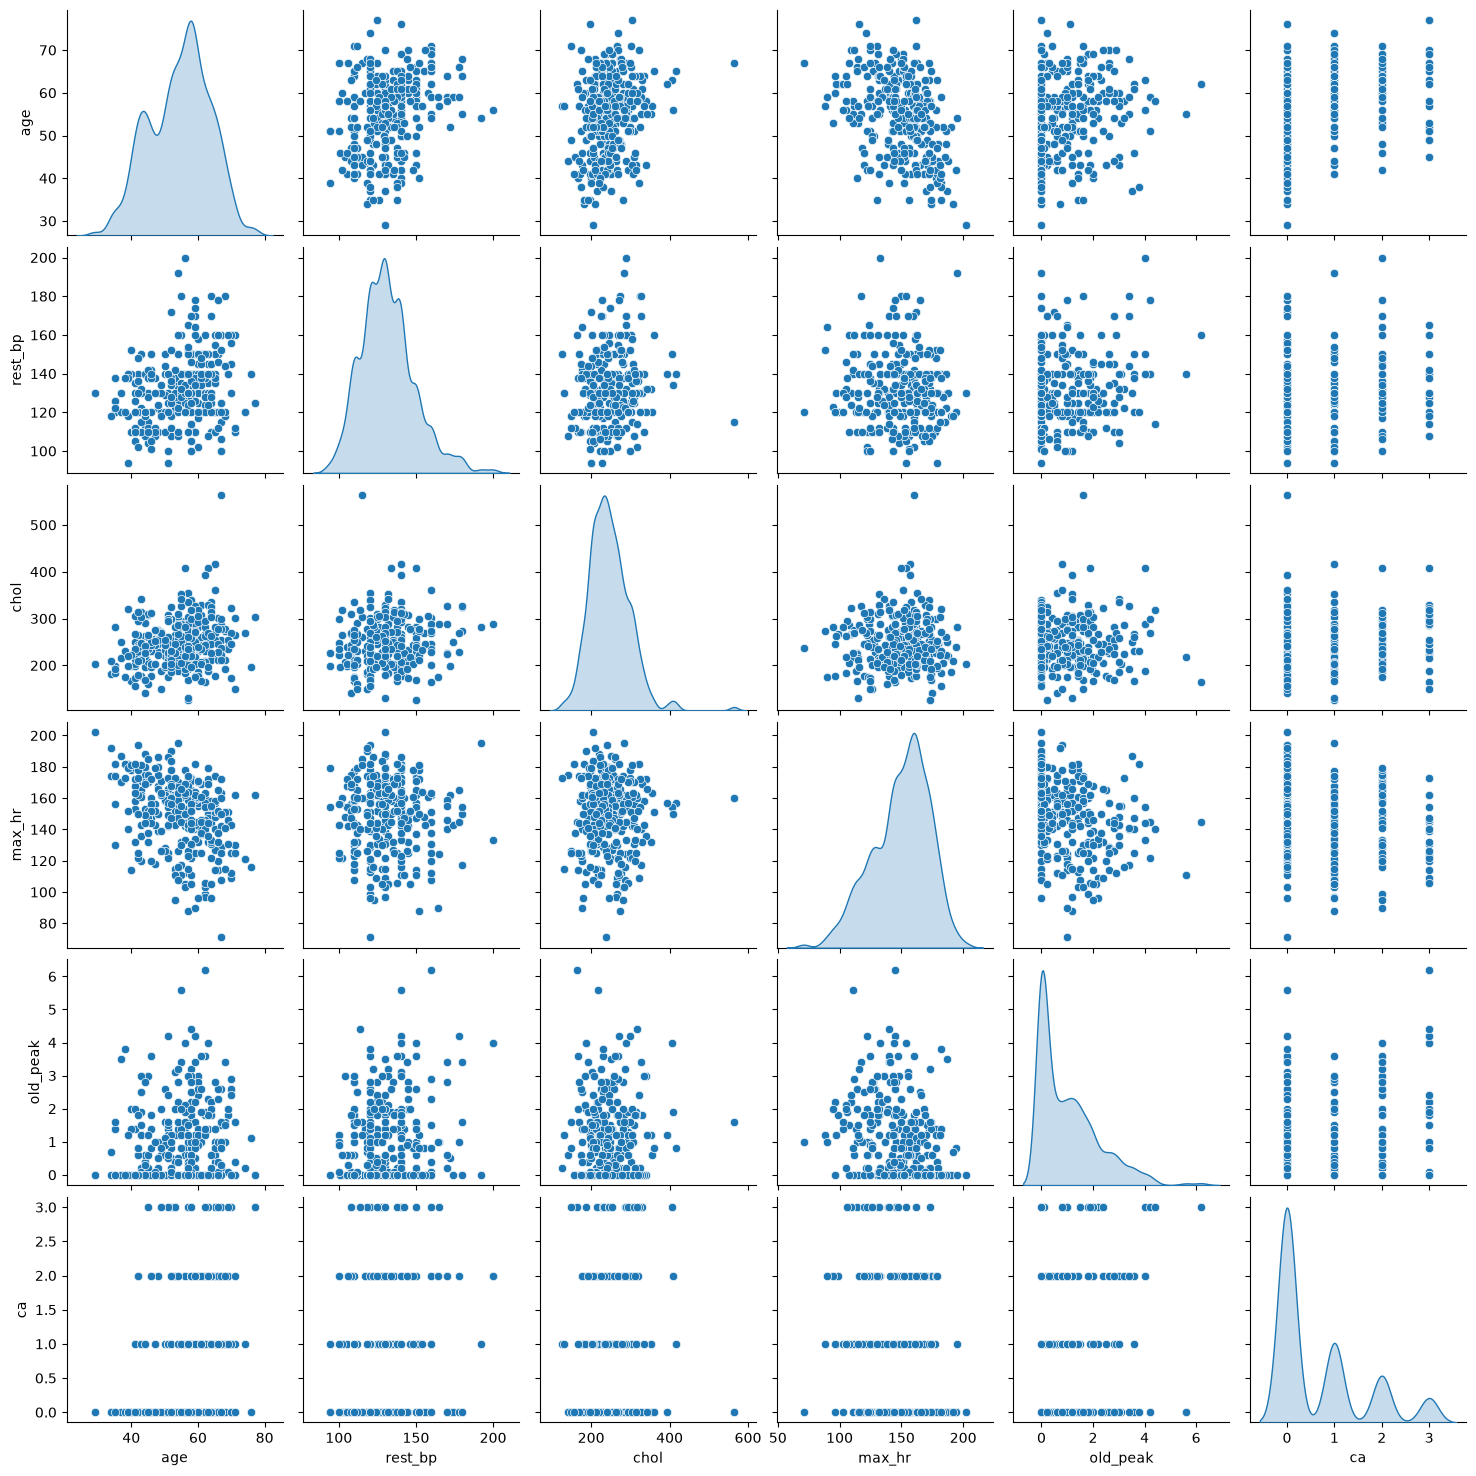

In [154]:
sns.pairplot(corazon_df[numerical_columns], diag_kind="kde");

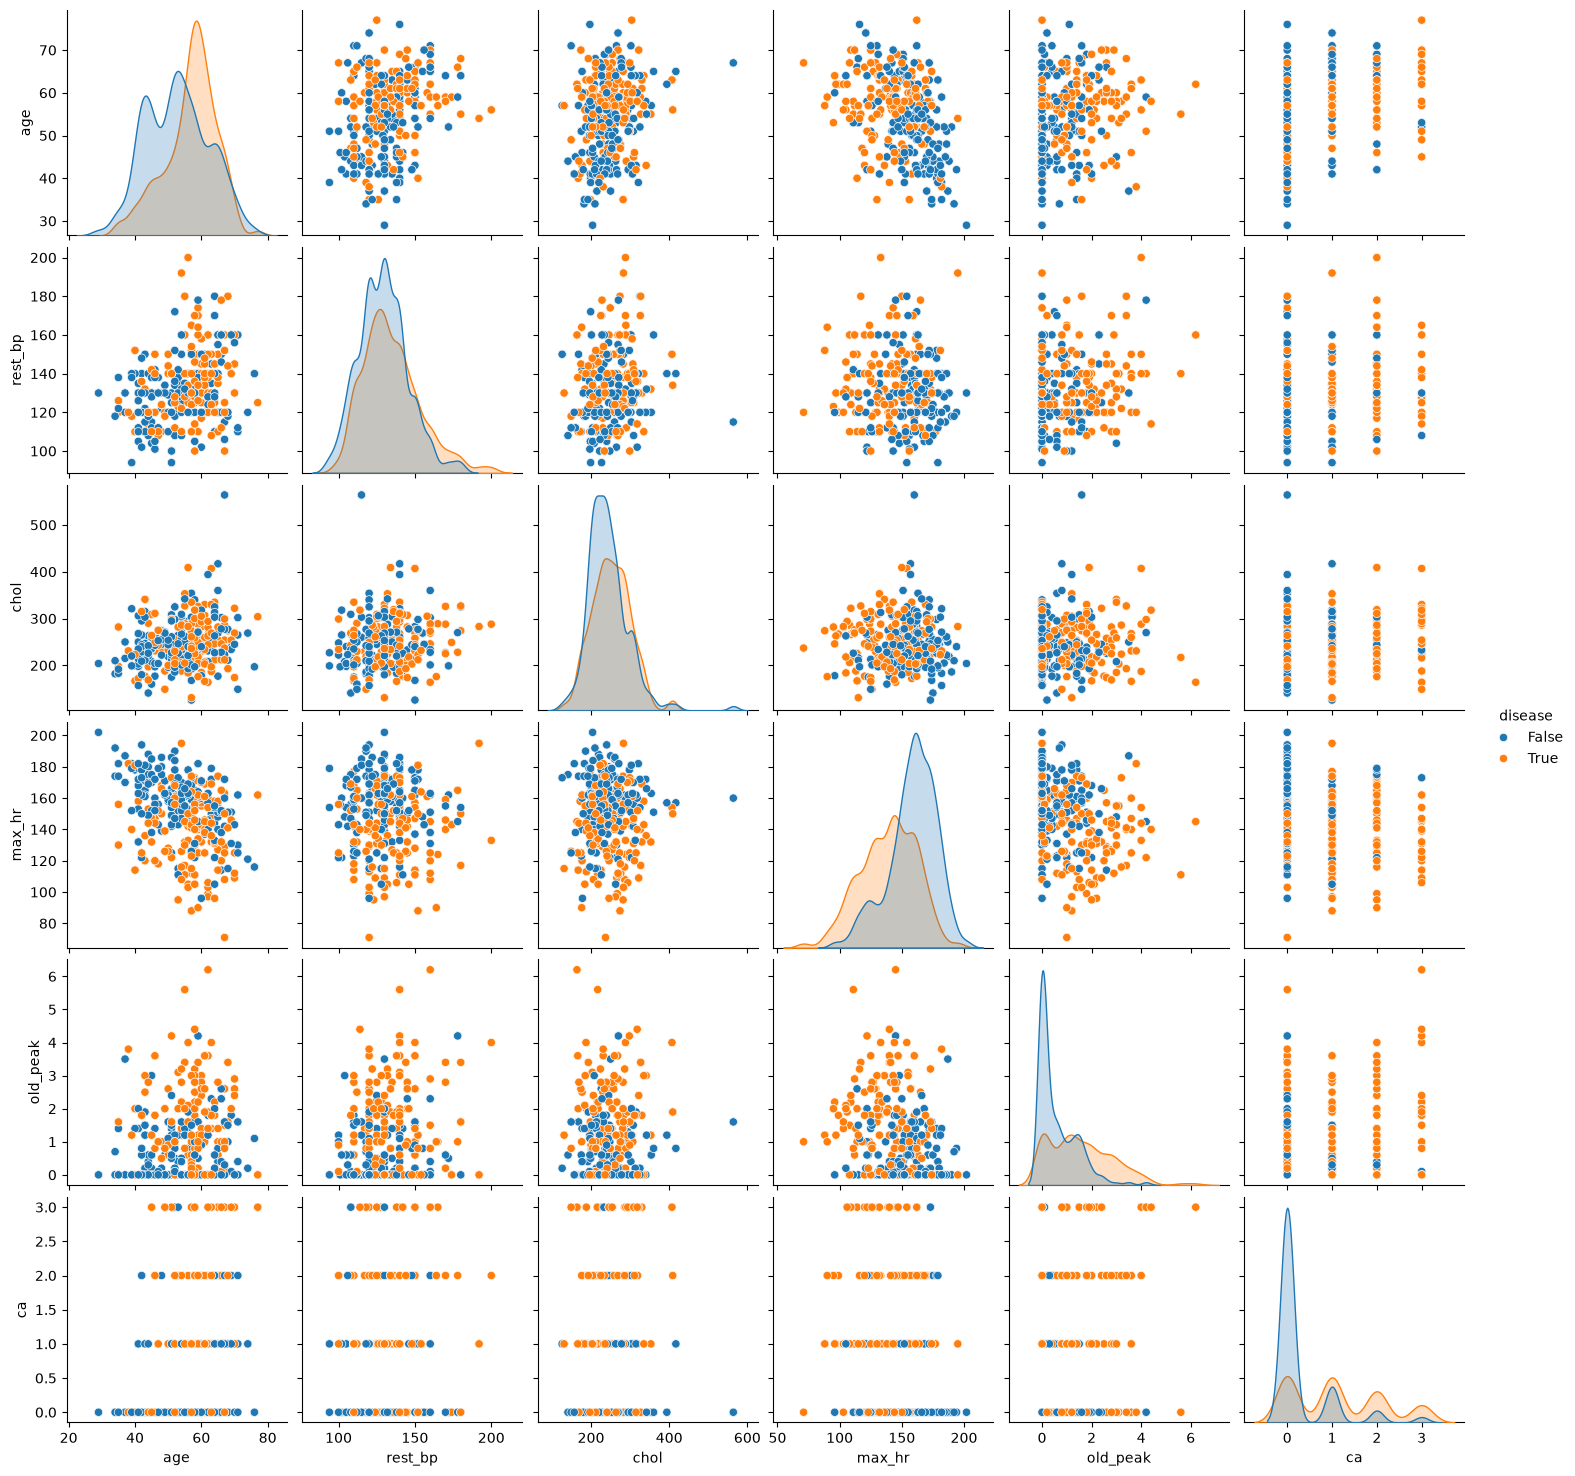

In [ ]:
df = corazon_df[[*numerical_columns, "disease"]].dropna(subset=[*numerical_columns, "disease"])
sns.pairplot(df, hue="disease", diag_kind="kde");

## 📏 Heuristics baseline model

Como primer acercamiento a un modelo, se construye un modelo base heurístico simple usando `sex`, `chest_pain` y `age`, calculando el porcentaje de pacientes con enfermedad para distintas combinaciones de tipo de dolor de pecho y rango de edad.

In [156]:
corazon_df["chest_pain"].unique()

['typical', 'asymptomatic', 'nonanginal', 'nontypical', NaN]
Categories (4, str): ['asymptomatic', 'nonanginal', 'nontypical', 'typical']

In [ ]:
def calculate_disease_percentage(df, chest_pain_type, age_min, age_max=None) -> float | None:
    """Calculate the percentage of patients with disease based on chest pain type and age range.

    Args:
        df: DataFrame with the heart disease dataset
        chest_pain_type: chest pain category to filter
        age_min: int with the minimum age of the patient
        age_max: int with the maximum age of the patient

    Returns:
        float with the percentage of patients with disease, or None if there are no
        patients in that group
    """
    if age_max:
        sick = len(
            df[
                (df["chest_pain"] == chest_pain_type)
                & (df["age"] > age_min)
                & (df["age"] < age_max)
                & (df["disease"])
            ]
        )
        total = len(
            df[
                (df["chest_pain"] == chest_pain_type)
                & (df["age"] > age_min)
                & (df["age"] < age_max)
            ]
        )
    else:
        sick = len(
            df[(df["chest_pain"] == chest_pain_type) & (df["age"] > age_min) & (df["disease"])]
        )
        total = len(df[(df["chest_pain"] == chest_pain_type) & (df["age"] > age_min)])

    if total == 0:
        return None
    return round((sick / total) * 100, 1)

In [158]:
result = calculate_disease_percentage(corazon_df, "typical", 60)
print(
    "typical, >60 años:",
    f"{result}%" if result is not None else "sin pacientes en este grupo",
)

result = calculate_disease_percentage(corazon_df, "typical", 20, 30)
print(
    "typical, 20-30 años:",
    f"{result}%" if result is not None else "sin pacientes en este grupo",
)

typical, >60 años: 22.8%
typical, 20-30 años: sin pacientes en este grupo


In [160]:
result = calculate_disease_percentage(corazon_df, "asymptomatic", 60)
print(
    "asymptomatic, >60 años:",
    f"{result}%" if result is not None else "sin pacientes en este grupo",
)

result = calculate_disease_percentage(corazon_df, "asymptomatic", 20, 30)
print(
    "asymptomatic, 20-30 años:",
    f"{result}%" if result is not None else "sin pacientes en este grupo",
)

asymptomatic, >60 años: 74.7%
asymptomatic, 20-30 años: sin pacientes en este grupo


In [161]:
result = calculate_disease_percentage(corazon_df, "nonanginal", 60)
print(
    "nonanginal, >60 años:",
    f"{result}%" if result is not None else "sin pacientes en este grupo",
)

result = calculate_disease_percentage(corazon_df, "nonanginal", 20, 30)
print(
    "nonanginal, 20-30 años:",
    f"{result}%" if result is not None else "sin pacientes en este grupo",
)

nonanginal, >60 años: 32.2%
nonanginal, 20-30 años: sin pacientes en este grupo


In [162]:
result = calculate_disease_percentage(corazon_df, "nontypical", 60)
print(
    "nontypical, >60 años:",
    f"{result}%" if result is not None else "sin pacientes en este grupo",
)

result = calculate_disease_percentage(corazon_df, "nontypical", 20, 30)
print(
    "nontypical, 20-30 años:",
    f"{result}%" if result is not None else "sin pacientes en este grupo",
)

nontypical, >60 años: 28.6%
nontypical, 20-30 años: 0.0%


## 📊 Analysis of Results

## 📊 Analysis of Results

### Edad en combinación con variables categóricas

En las cinco variables categóricas analizadas junto con `age` (sex, chest_pain, exang, slope, thal), el patrón es consistente: dentro de cada categoría, el grupo de pacientes con `disease=True` tiene una mediana de edad más alta que el grupo `disease=False`. La única excepción visual es la categoría "typical" de `chest_pain`, donde ambas medianas de edad se ven muy similares.

Esto confirma, ahora considerando una tercera variable a la vez, lo que ya habíamos visto en el análisis bivariable (03b): la edad está asociada con la enfermedad de forma bastante estable, sin importar con qué otra variable categórica se cruce.

### Sexo y thal

La tabla agrupada muestra el porcentaje de enfermedad por combinación de `thal` y `sex`:

| thal | Female | Male |
|---|---|---|
| fixed | 100.00% | 65.82% |
| normal | 14.27% | 29.77% |
| reversable | 87.32% | 74.51% |

En las tres categorías de `thal`, las mujeres presentan un porcentaje de enfermedad mayor que los hombres, con la excepción de "normal", donde ambos sexos tienen tasas bajas pero los hombres superan a las mujeres (29.77% vs 14.27%).

En otras palabras: `thal` es un fuerte indicador de riesgo en ambos sexos, pero cuando hay enfermedad de este tipo (fixed o reversable), afecta a las mujeres del dataset con una frecuencia incluso mayor que a los hombres.

### Thal y max_hr

Dentro de cada categoría de `thal`, el grupo de pacientes con enfermedad tiene una mediana de `max_hr` (frecuencia cardíaca máxima) más baja que el grupo sin enfermedad — por ejemplo, en `thal="normal"`, la mediana es de aproximadamente 148 para quienes tienen la enfermedad, frente a 163 para quienes no la tienen.

Esto confirma que la relación inversa entre `max_hr` y la enfermedad, identificada en el análisis bivariable, se mantiene incluso al controlar por el tipo de `thal`.

### Sexo, thal y exang

La tabla cruzando `exang`, `thal` y `sex` muestra que, dentro de cada combinación de thal y sexo, tener `exang=True` (angina inducida por ejercicio) aumenta consistentemente el porcentaje de enfermedad:

- Mujeres, thal="normal": 9.3% (sin exang) vs 38.1% (con exang)
- Hombres, thal="normal": 22.7% (sin exang) vs 54.8% (con exang)
- Mujeres, thal="reversable": 73.4% (sin exang) vs 100.0% (con exang)
- Hombres, thal="reversable": 60.6% (sin exang) vs 87.6% (con exang)
- Hombres, thal="fixed": 50.0% (sin exang) vs 86.2% (con exang)

También se identificó un vacío de datos: no hay ningún registro de mujeres con `thal="fixed"` y `exang=False` en la muestra.

Esto sugiere que `exang` funciona como un factor de riesgo adicional que se suma al de `thal`, más que como una variable redundante — la combinación de ambas condiciones eleva el riesgo por encima de lo que cada una muestra por separado.

### Relaciones entre variables numéricas

Al revisar todas las combinaciones de las 6 variables numéricas (age, rest_bp, chol, max_hr, old_peak, ca) no se observan correlaciones lineales fuertes entre ellas, salvo la tendencia negativa moderada ya conocida entre `age` y `max_hr`. Al colorear los mismos gráficos por `disease`, se nota una separación clara en las distribuciones de `age`, `max_hr`, `old_peak` y `ca` entre pacientes con y sin enfermedad, mientras que `rest_bp` y `chol` se solapan casi por completo entre ambos grupos.

Esto refuerza que `age`, `max_hr`, `old_peak` y `ca` son las variables numéricas con mayor poder para distinguir pacientes con y sin enfermedad, mientras que `rest_bp` y `chol` aportan poco por sí solas — coincidiendo con lo encontrado en el análisis bivariable.

### Modelo heurístico (sex, chest_pain, age)

Para pacientes mayores de 60 años, el porcentaje de enfermedad según el tipo de dolor de pecho fue:

- asymptomatic: 74.7%
- nonanginal: 32.2%
- nontypical: 28.6%
- typical: 22.8%

Para el rango de 20 a 30 años, el dataset tiene muy pocos pacientes: no hay ningún registro en las categorías "typical", "asymptomatic" ni "nonanginal", y en "nontypical" el porcentaje de enfermedad fue 0.0%.

Esto muestra que el tipo de dolor de pecho, combinado con la edad, ya permite distinguir grupos de riesgo muy distintos entre los pacientes mayores (de 22.8% a 74.7% según la categoría), replicando en nuestro dataset la misma lógica de "modelo base heurístico" que la guía aplicó con sex, pclass y age en el Titanic. Sin embargo, la falta de pacientes jóvenes en el dataset significa que este modelo heurístico no puede evaluarse de forma confiable para ese grupo de edad.

### Resumen

El análisis multivariable confirma y refuerza los hallazgos del análisis bivariable: la enfermedad está asociada principalmente con `thal`, `exang`, `age`, `max_hr`, `old_peak`, `ca` y `sex`, y estas asociaciones se mantienen — e incluso se combinan de forma acumulativa — cuando se analizan en conjunto en vez de una por una. Las variables `rest_bp` y `chol` siguen mostrando poca capacidad de discriminación en cualquier combinación revisada. Un modelo base simple usando `sex`, `chest_pain` y `age` ya logra diferenciar grupos con porcentajes de enfermedad muy distintos entre sí, lo que sugiere que estas variables serán útiles como punto de partida para un modelo de clasificación más completo.

## 💡 Proposals and Ideas

Para el primer modelo base, se propone usar las variables `sex`, `chest_pain`, `thal`, `exang`, `age`, `max_hr`, `old_peak` y `ca`, ya que son las que mostraron mayor asociación con la enfermedad tanto en el análisis bivariable como en el multivariable. Se recomienda evaluar si combinaciones como `thal + exang` aportan más valor predictivo juntas que por separado, dado el efecto acumulativo observado. También conviene decidir cómo tratar los valores nulos de `disease` (111 registros) antes de la etapa de modelado, ya que esas filas no podrán usarse para entrenar un modelo supervisado.